In [3]:
import os
import re
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from skimage.measure import label

In [4]:
pwd


'/scratch/user/s4906996/Cellpose SAM'

In [5]:
base_dir = "/scratch/user/s4906996/Cellpose SAM"   

sam_dir = os.path.join(base_dir, "cellpose_sam_results")
manual_dir = os.path.join(base_dir, "manual_segmentation_masks")

print("SAM dir exists:", os.path.exists(sam_dir))
print("Manual dir exists:", os.path.exists(manual_dir))

SAM dir exists: True
Manual dir exists: True


In [6]:
#listing files 
sam_files = sorted([f for f in os.listdir(sam_dir) if f.lower().endswith((".tif", ".tiff"))])
manual_files = sorted([f for f in os.listdir(manual_dir) if f.lower().endswith((".tif", ".tiff"))])

print("SAM files:")
for f in sam_files[:10]:
    print("  ", f)

print("\nManual files:")
for f in manual_files[:10]:
    print("  ", f)

SAM files:
   614399S2D20250113_sam_masks.tif
   614399s1d120250113_sam_masks.tif
   614399s1d20241213_sam_masks.tif
   614399s1d20250108_sam_masks.tif
   614400s1d20241218_sam_masks.tif
   614400s1d20250108_sam_masks.tif
   614401s1d20250114_sam_masks.tif
   614401s1d20250414_sam_masks.tif
   614404s1d20250115_sam_masks.tif
   671461s1d20250728_sam_masks.tif

Manual files:
   614399S2D20250113 2_mask.tiff
   614399s1d120250113 2_mask.tiff
   614399s1d20241213 2_mask.tiff
   614399s1d20250108 2_mask.tiff
   614400s1d20241218 2_mask.tiff
   614400s1d20250108 2_mask.tiff
   614401s1d20250114 2_mask.tiff
   614401s1d20250414 2_mask.tiff
   614404s1d20250115 2_mask.tiff
   671480s1d20250709 2_mask.tiff


In [7]:
#extract common files from filenames
def extract_base_id_sam(filename):
    """
    Example:
    614399s1d20241213_sam_masks.tif -> 614399s1d20241213
    """
    name = os.path.splitext(filename)[0]
    return name.replace("_sam_masks", "")

def extract_base_id_manual(filename):
    """
    Example:
    614399s1d20241213 2_mask.tiff -> 614399s1d20241213
    """
    name = os.path.splitext(filename)[0]
    match = re.match(r"^(.*?)\s+\d+_mask$", name)
    if match:
        return match.group(1)
    return name

In [8]:
#building matching file pairs. 
sam_map = {extract_base_id_sam(f): f for f in sam_files}
manual_map = {extract_base_id_manual(f): f for f in manual_files}

common_ids = sorted(set(sam_map.keys()) & set(manual_map.keys()))

print("Number of matched image pairs:", len(common_ids))
print("Some matched IDs:", common_ids[:10])

Number of matched image pairs: 16
Some matched IDs: ['614399S2D20250113', '614399s1d120250113', '614399s1d20241213', '614399s1d20250108', '614400s1d20241218', '614400s1d20250108', '614401s1d20250114', '614401s1d20250414', '614404s1d20250115', '671480s1d20250709']


In [9]:
#picking one matched pair 

pair_index = 0   # change this if needed

image_id = common_ids[pair_index]

sam_file = os.path.join(sam_dir, sam_map[image_id])
manual_file = os.path.join(manual_dir, manual_map[image_id])

print("Selected image ID:", image_id)
print("SAM file:", sam_file)
print("Manual file:", manual_file)

Selected image ID: 614399S2D20250113
SAM file: /scratch/user/s4906996/Cellpose SAM/cellpose_sam_results/614399S2D20250113_sam_masks.tif
Manual file: /scratch/user/s4906996/Cellpose SAM/manual_segmentation_masks/614399S2D20250113 2_mask.tiff


In [10]:
#load 2 masks 
sam_mask = tiff.imread(sam_file)
manual_mask = tiff.imread(manual_file)

print("SAM shape:", sam_mask.shape, "dtype:", sam_mask.dtype)
print("Manual shape:", manual_mask.shape, "dtype:", manual_mask.dtype)

SAM shape: (512, 512) dtype: uint16
Manual shape: (512, 512) dtype: uint16


In [11]:
#visualize mask 
sam_mask = tiff.imread(sam_file)
manual_mask = tiff.imread(manual_file)

print("SAM shape:", sam_mask.shape, "dtype:", sam_mask.dtype)
print("Manual shape:", manual_mask.shape, "dtype:", manual_mask.dtype)

SAM shape: (512, 512) dtype: uint16
Manual shape: (512, 512) dtype: uint16


In [22]:
#Convert masks into labeled instances if needed 

# Masks are already instance-labeled, so use them directly
sam_labeled = sam_mask.copy()
manual_labeled = manual_mask.copy()

sam_labels = np.unique(sam_labeled)
manual_labels = np.unique(manual_labeled)

sam_labels = sam_labels[sam_labels != 0]
manual_labels = manual_labels[manual_labels != 0]

print("SAM labels:", sam_labels)
print("Manual labels:", manual_labels)

print("Number of SAM ROIs:", len(sam_labels))
print("Number of Manual ROIs:", len(manual_labels))

SAM labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Manual labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Number of SAM ROIs: 21
Number of Manual ROIs: 21


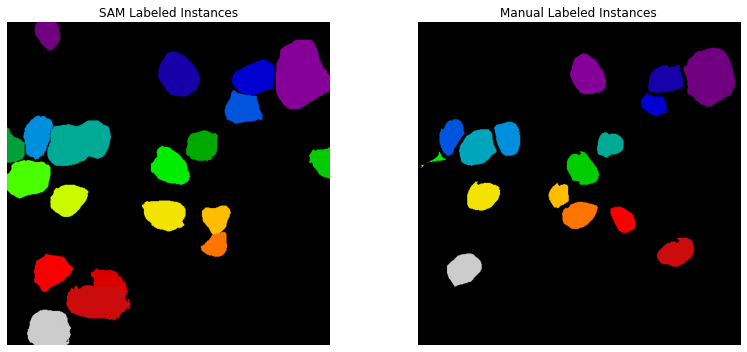

In [23]:
#visualize labelled masks. 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sam_labeled, cmap="nipy_spectral")
plt.title("SAM Labeled Instances")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(manual_labeled, cmap="nipy_spectral")
plt.title("Manual Labeled Instances")
plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
#Compute IOU and Dice 
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    return (2 * intersection / total) if total > 0 else 0.0

In [25]:
#in this fucntion i am finding the best match of SAM and manual Mask to focus on that roi 
def find_best_match_for_manual_roi(manual_label_id, sam_labeled, manual_labeled):
    manual_roi = (manual_labeled == manual_label_id)
    
    best_sam_label = None
    best_iou = -1
    
    for sam_label_id in range(1, sam_labeled.max() + 1):
        sam_roi = (sam_labeled == sam_label_id)
        iou = compute_iou(sam_roi, manual_roi)
        
        if iou > best_iou:
            best_iou = iou
            best_sam_label = sam_label_id
    
    return best_sam_label, best_iou

In [26]:
manual_roi_label = 1   # change this to test different manual ROIs

best_sam_label, best_iou = find_best_match_for_manual_roi(
    manual_roi_label,
    sam_labeled,
    manual_labeled
)

print("Manual ROI label:", manual_roi_label)
print("Best matched SAM ROI label:", best_sam_label)
print("Best IoU before final reporting:", best_iou)

Manual ROI label: 1
Best matched SAM ROI label: 2
Best IoU before final reporting: 0.7683413626978665


In [27]:
manual_roi_label = 1   # change this to test different manual ROIs

best_sam_label, best_iou = find_best_match_for_manual_roi(
    manual_roi_label,
    sam_labeled,
    manual_labeled
)

print("Manual ROI label:", manual_roi_label)
print("Best matched SAM ROI label:", best_sam_label)
print("Best IoU before final reporting:", best_iou)

Manual ROI label: 1
Best matched SAM ROI label: 2
Best IoU before final reporting: 0.7683413626978665


In [28]:
manual_roi = (manual_labeled == manual_roi_label)
sam_roi = (sam_labeled == best_sam_label)

print("Manual ROI pixels:", manual_roi.sum())
print("SAM ROI pixels:", sam_roi.sum())

Manual ROI pixels: 5662
SAM ROI pixels: 7185


In [29]:
iou = compute_iou(sam_roi, manual_roi)
dice = compute_dice(sam_roi, manual_roi)

print(f"IoU  = {iou:.4f}")
print(f"Dice = {dice:.4f}")

IoU  = 0.7683
Dice = 0.8690


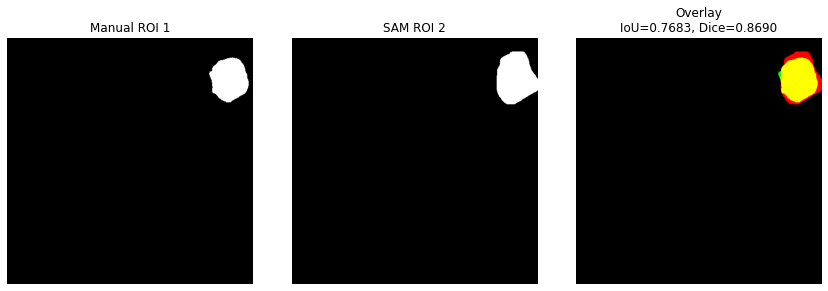

In [30]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(manual_roi, cmap="gray")
plt.title(f"Manual ROI {manual_roi_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sam_roi, cmap="gray")
plt.title(f"SAM ROI {best_sam_label}")
plt.axis("off")

overlay = np.zeros((*manual_roi.shape, 3), dtype=np.float32)
overlay[..., 0] = sam_roi.astype(float)      # red = SAM
overlay[..., 1] = manual_roi.astype(float)   # green = Manual

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay\nIoU={iou:.4f}, Dice={dice:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
print(np.unique(sam_mask))
print(np.unique(manual_mask))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


In [31]:
sam_labeled = sam_mask.copy()
manual_labeled = manual_mask.copy()

sam_labels = np.unique(sam_labeled)
manual_labels = np.unique(manual_labeled)

sam_labels = sam_labels[sam_labels != 0]
manual_labels = manual_labels[manual_labels != 0]

print("SAM labels:", sam_labels)
print("Manual labels:", manual_labels)
print("Number of SAM ROIs:", len(sam_labels))
print("Number of Manual ROIs:", len(manual_labels))

SAM labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Manual labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Number of SAM ROIs: 21
Number of Manual ROIs: 21


In [32]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    return (2 * intersection / total) if total > 0 else 0.0

In [33]:
def find_best_match_for_manual_roi(manual_label_id, sam_labeled, manual_labeled):
    manual_roi = (manual_labeled == manual_label_id)

    best_sam_label = None
    best_iou = -1

    sam_labels = np.unique(sam_labeled)
    sam_labels = sam_labels[sam_labels != 0]

    for sam_label_id in sam_labels:
        sam_roi = (sam_labeled == sam_label_id)
        iou = compute_iou(sam_roi, manual_roi)

        if iou > best_iou:
            best_iou = iou
            best_sam_label = sam_label_id

    return best_sam_label, best_iou

In [34]:
manual_roi_label = 1

best_sam_label, best_iou = find_best_match_for_manual_roi(
    manual_roi_label,
    sam_labeled,
    manual_labeled
)

manual_roi = (manual_labeled == manual_roi_label)
sam_roi = (sam_labeled == best_sam_label)

iou = compute_iou(sam_roi, manual_roi)
dice = compute_dice(sam_roi, manual_roi)

print("Manual ROI:", manual_roi_label)
print("Best SAM ROI:", best_sam_label)
print(f"IoU:  {iou:.4f}")
print(f"Dice: {dice:.4f}")

Manual ROI: 1
Best SAM ROI: 2
IoU:  0.7683
Dice: 0.8690


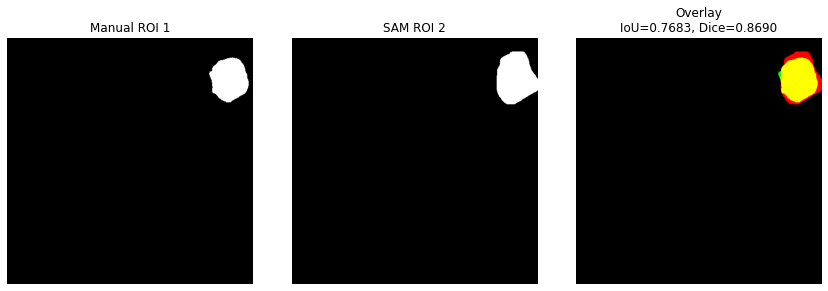

In [35]:
#visualize corrected pair 

import matplotlib.pyplot as plt

overlay = np.zeros((*manual_roi.shape, 3), dtype=np.float32)
overlay[..., 0] = sam_roi.astype(float)      # red
overlay[..., 1] = manual_roi.astype(float)   # green

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(manual_roi, cmap="gray")
plt.title(f"Manual ROI {manual_roi_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sam_roi, cmap="gray")
plt.title(f"SAM ROI {best_sam_label}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay\nIoU={iou:.4f}, Dice={dice:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
#check few ROI 

for manual_roi_label in [1, 2, 3, 4, 5]:
    best_sam_label, _ = find_best_match_for_manual_roi(
        manual_roi_label, sam_labeled, manual_labeled
    )

    manual_roi = (manual_labeled == manual_roi_label)
    sam_roi = (sam_labeled == best_sam_label)

    iou = compute_iou(sam_roi, manual_roi)
    dice = compute_dice(sam_roi, manual_roi)

    print(f"Manual ROI {manual_roi_label} -> SAM ROI {best_sam_label} | IoU={iou:.4f}, Dice={dice:.4f}")

Manual ROI 1 -> SAM ROI 2 | IoU=0.7683, Dice=0.8690
Manual ROI 2 -> SAM ROI 3 | IoU=0.7808, Dice=0.8769
Manual ROI 3 -> SAM ROI 4 | IoU=0.7077, Dice=0.8288
Manual ROI 4 -> SAM ROI 5 | IoU=0.4657, Dice=0.6354
Manual ROI 5 -> SAM ROI 6 | IoU=0.6338, Dice=0.7759


In [38]:
#scaling to all manual ROI and save results 
results = []

for manual_roi_label in manual_labels:
    best_sam_label, _ = find_best_match_for_manual_roi(
        manual_roi_label, sam_labeled, manual_labeled
    )

    manual_roi = (manual_labeled == manual_roi_label)
    sam_roi = (sam_labeled == best_sam_label)

    iou = compute_iou(sam_roi, manual_roi)
    dice = compute_dice(sam_roi, manual_roi)

    results.append({
        "manual_roi": int(manual_roi_label),
        "matched_sam_roi": int(best_sam_label),
        "iou": float(iou),
        "dice": float(dice)
    })

print(results[:5])

[{'manual_roi': 1, 'matched_sam_roi': 2, 'iou': 0.7683413626978665, 'dice': 0.8689966529150774}, {'manual_roi': 2, 'matched_sam_roi': 3, 'iou': 0.7808417997097242, 'dice': 0.8769356153219234}, {'manual_roi': 3, 'matched_sam_roi': 4, 'iou': 0.7076977651649521, 'dice': 0.8288325716659742}, {'manual_roi': 4, 'matched_sam_roi': 5, 'iou': 0.46566901408450706, 'dice': 0.6354354354354355}, {'manual_roi': 5, 'matched_sam_roi': 6, 'iou': 0.6338147833474936, 'dice': 0.7758710348413936}]


In [40]:
!pip install pandas
import pandas as pd

results_df = pd.DataFrame(results)
results_df

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


,manual_roi,matched_sam_roi,iou,dice
0,1,2,0.768341,0.868997
1,2,3,0.780842,0.876936
2,3,4,0.707698,0.828833
3,4,5,0.465669,0.635435
4,5,6,0.633815,0.775871
5,6,8,0.304529,0.466880
6,7,8,0.462300,0.632292
7,8,10,0.633234,0.775435
8,9,6,0.000433,0.000865
9,10,6,0.000433,0.000865


In [41]:
pwd


'/scratch/user/s4906996/Cellpose SAM'

In [44]:
import numpy as np
import pandas as pd

def get_roi_info(label_img):
    roi_info = {}
    labels = np.unique(label_img)
    labels = labels[labels != 0]

    for lbl in labels:
        coords = np.argwhere(label_img == lbl)
        rmin, cmin = coords.min(axis=0)
        rmax, cmax = coords.max(axis=0)

        roi_info[int(lbl)] = {
            "coords": coords,
            "bbox": (rmin, rmax, cmin, cmax),
            "area": len(coords)
        }

    return roi_info

sam_info = get_roi_info(sam_labeled)
manual_info = get_roi_info(manual_labeled)

print("SAM ROIs:", len(sam_info))
print("Manual ROIs:", len(manual_info))

SAM ROIs: 21
Manual ROIs: 21


In [45]:
def bboxes_overlap(b1, b2):
    rmin1, rmax1, cmin1, cmax1 = b1
    rmin2, rmax2, cmin2, cmax2 = b2

    return not (rmax1 < rmin2 or rmax2 < rmin1 or cmax1 < cmin2 or cmax2 < cmin1)

In [46]:
def compute_iou_and_dice_from_labels(manual_label, sam_label, manual_labeled, sam_labeled, manual_info, sam_info):
    mb = manual_info[manual_label]["bbox"]
    sb = sam_info[sam_label]["bbox"]

    rmin = min(mb[0], sb[0])
    rmax = max(mb[1], sb[1])
    cmin = min(mb[2], sb[2])
    cmax = max(mb[3], sb[3])

    manual_crop = (manual_labeled[rmin:rmax+1, cmin:cmax+1] == manual_label)
    sam_crop = (sam_labeled[rmin:rmax+1, cmin:cmax+1] == sam_label)

    intersection = np.logical_and(manual_crop, sam_crop).sum()
    union = np.logical_or(manual_crop, sam_crop).sum()
    total = manual_crop.sum() + sam_crop.sum()

    iou = intersection / union if union > 0 else 0.0
    dice = (2 * intersection / total) if total > 0 else 0.0

    return iou, dice

In [47]:
def fast_match_all_rois(manual_labeled, sam_labeled, manual_info, sam_info):
    results = []

    for m_label, m_data in manual_info.items():
        m_bbox = m_data["bbox"]

        best_sam = None
        best_iou = -1
        best_dice = -1

        for s_label, s_data in sam_info.items():
            s_bbox = s_data["bbox"]

            # Skip impossible matches
            if not bboxes_overlap(m_bbox, s_bbox):
                continue

            iou, dice = compute_iou_and_dice_from_labels(
                m_label, s_label,
                manual_labeled, sam_labeled,
                manual_info, sam_info
            )

            if iou > best_iou:
                best_iou = iou
                best_dice = dice
                best_sam = s_label

        # If no overlapping SAM ROI found
        if best_sam is None:
            best_sam = -1
            best_iou = 0.0
            best_dice = 0.0

        results.append({
            "manual_roi": m_label,
            "matched_sam_roi": best_sam,
            "iou": best_iou,
            "dice": best_dice,
            "manual_area": manual_info[m_label]["area"]
        })

    return results

In [48]:
results = fast_match_all_rois(
    manual_labeled,
    sam_labeled,
    manual_info,
    sam_info
)

results_df = pd.DataFrame(results)
results_df

,manual_roi,matched_sam_roi,iou,dice,manual_area
0,1,2,0.768341,0.868997,5662
1,2,3,0.780842,0.876936,2690
2,3,4,0.707698,0.828833,1995
3,4,5,0.465669,0.635435,1058
4,5,6,0.633815,0.775871,1536
5,6,8,0.304529,0.466880,1751
6,7,8,0.462300,0.632292,2521
7,8,10,0.633234,0.775435,1290
8,9,6,0.000433,0.000865,1
9,10,6,0.000433,0.000865,1


In [49]:
#Instead of plotting all ROIs, which is slow and noisy, plot only:

# worst 5

# best 5

In [50]:
worst5 = results_df.sort_values("iou").head(5)
worst5

,manual_roi,matched_sam_roi,iou,dice,manual_area
19,20,-1,0.000000,0.000000,1914
12,13,13,0.000300,0.000601,1
18,19,15,0.000381,0.000762,1
8,9,6,0.000433,0.000865,1
9,10,6,0.000433,0.000865,1


In [51]:
import matplotlib.pyplot as plt

def visualize_roi_pair(manual_label, sam_label, manual_labeled, sam_labeled, pad=15):
    if sam_label == -1:
        print(f"Manual ROI {manual_label}: no matched SAM ROI")
        return

    manual_roi = (manual_labeled == manual_label)
    sam_roi = (sam_labeled == sam_label)

    coords = np.argwhere(np.logical_or(manual_roi, sam_roi))
    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)

    rmin = max(rmin - pad, 0)
    cmin = max(cmin - pad, 0)
    rmax = min(rmax + pad + 1, manual_labeled.shape[0])
    cmax = min(cmax + pad + 1, manual_labeled.shape[1])

    manual_crop = manual_roi[rmin:rmax, cmin:cmax]
    sam_crop = sam_roi[rmin:rmax, cmin:cmax]

    intersection = np.logical_and(manual_crop, sam_crop).sum()
    union = np.logical_or(manual_crop, sam_crop).sum()
    total = manual_crop.sum() + sam_crop.sum()

    iou = intersection / union if union > 0 else 0.0
    dice = (2 * intersection / total) if total > 0 else 0.0

    overlay = np.zeros((*manual_crop.shape, 3), dtype=np.float32)
    overlay[..., 0] = sam_crop.astype(float)
    overlay[..., 1] = manual_crop.astype(float)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(manual_crop, cmap="gray")
    plt.title(f"Manual ROI {manual_label}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sam_crop, cmap="gray")
    plt.title(f"SAM ROI {sam_label}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nIoU={iou:.4f}, Dice={dice:.4f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Manual ROI 20: no matched SAM ROI


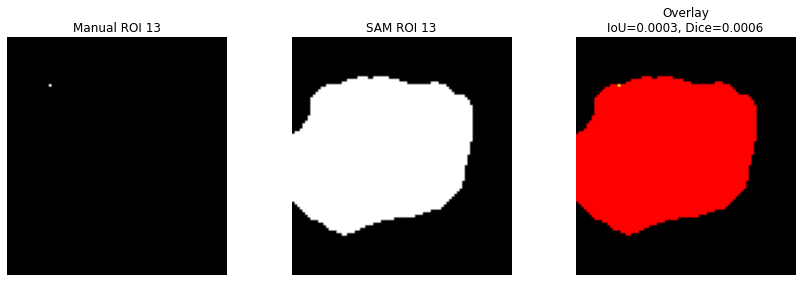

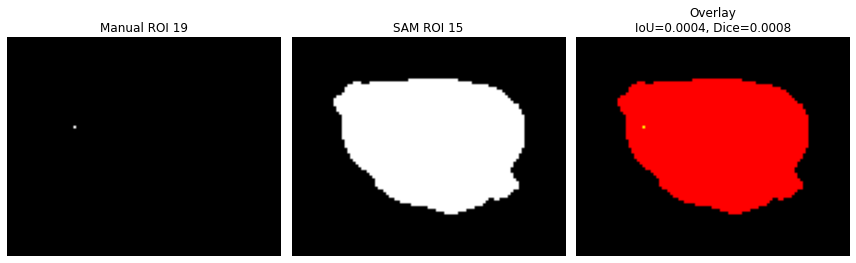

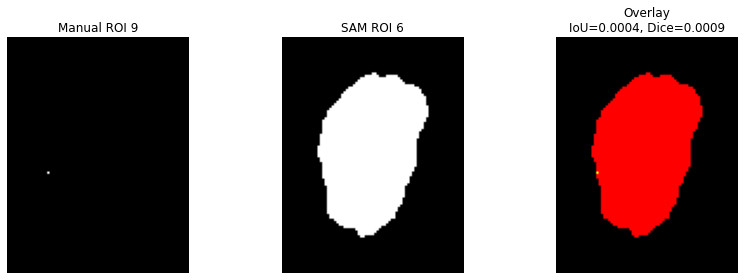

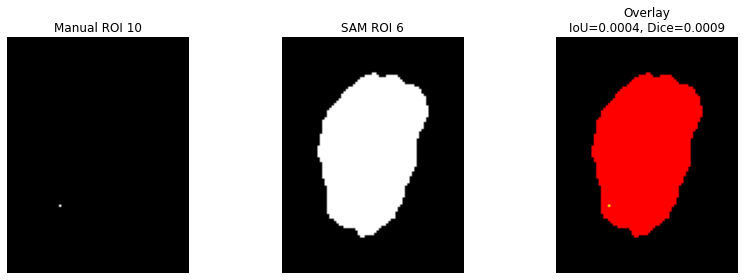

In [52]:
for _, row in worst5.iterrows():
    visualize_roi_pair(
        int(row["manual_roi"]),
        int(row["matched_sam_roi"]),
        manual_labeled,
        sam_labeled
    )

In [53]:
#creating ROI map 
import numpy as np
import matplotlib.pyplot as plt

# Build a dictionary: manual ROI label -> IoU
iou_dict = dict(zip(results_df["manual_roi"], results_df["iou"]))
dice_dict = dict(zip(results_df["manual_roi"], results_df["dice"]))

# Create full-size image where each manual ROI pixel gets its IoU value
iou_map = np.zeros_like(manual_labeled, dtype=float)

for roi_label, iou_value in iou_dict.items():
    iou_map[manual_labeled == roi_label] = iou_value

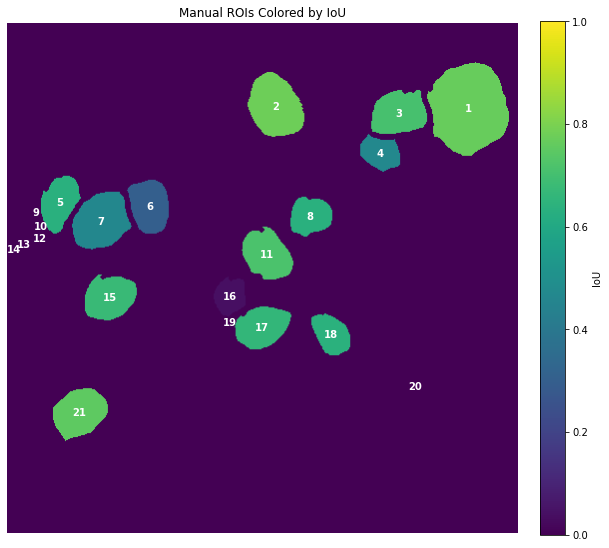

In [54]:
from skimage.measure import regionprops

plt.figure(figsize=(10, 10))
im = plt.imshow(iou_map, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="IoU")
plt.title("Manual ROIs Colored by IoU")
plt.axis("off")

# Write ROI label number at centroid of each manual ROI
props = regionprops(manual_labeled)

for prop in props:
    y, x = prop.centroid
    roi_label = prop.label
    plt.text(
        x, y, str(roi_label),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        weight="bold"
    )

plt.show()

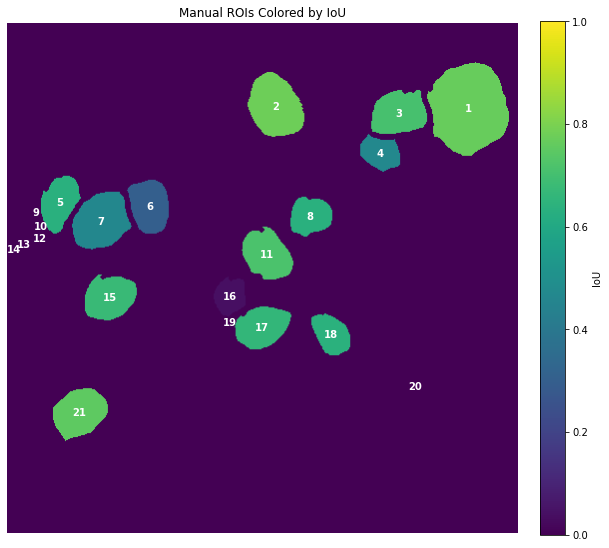

In [55]:
from skimage.measure import regionprops

plt.figure(figsize=(10, 10))
im = plt.imshow(iou_map, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="IoU")
plt.title("Manual ROIs Colored by IoU")
plt.axis("off")

# Write ROI label number at centroid of each manual ROI
props = regionprops(manual_labeled)

for prop in props:
    y, x = prop.centroid
    roi_label = prop.label
    plt.text(
        x, y, str(roi_label),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        weight="bold"
    )

plt.show()

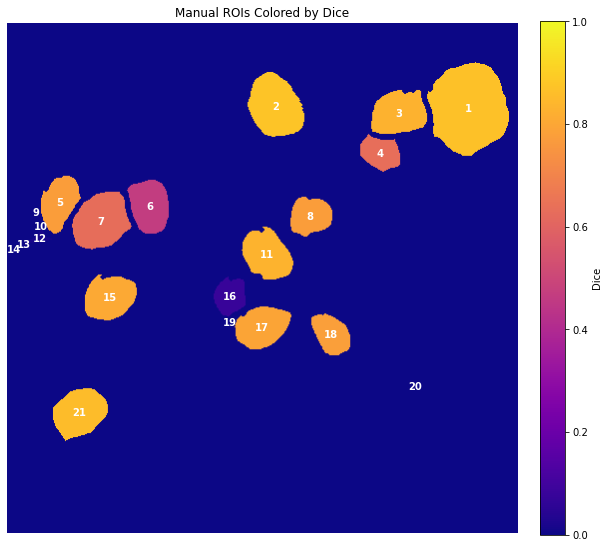

In [56]:
#FOR dICE 
dice_map = np.zeros_like(manual_labeled, dtype=float)

for roi_label, dice_value in dice_dict.items():
    dice_map[manual_labeled == roi_label] = dice_value

plt.figure(figsize=(10, 10))
im = plt.imshow(dice_map, cmap="plasma", vmin=0, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Dice")
plt.title("Manual ROIs Colored by Dice")
plt.axis("off")

props = regionprops(manual_labeled)

for prop in props:
    y, x = prop.centroid
    roi_label = prop.label
    plt.text(
        x, y, str(roi_label),
        color="white",
        fontsize=10,
        ha="center",
        va="center",
        weight="bold"
    )

plt.show()